# Temporal Node Precition with Timeseries Data.

This tutorial showcases the native ingestion of timeseries data in GraphFlow (DGF). After completing this tutorial, the reader will have learned about incorporating node level timeseries features. This allows them to model dynamic networks (such as telecommunication and traffic graphs) more effectively.

## 1. Native Timeseries vs Graph Representation


In [Node Model Tutorial](link_node_prediction.md), we showcased predicting node features on temporal and static graphs. For temporal graphs, we learned that a `creation_time` can be specified for nodes. This enables us to model temporal phenomena.

A single node often observes a stream of data points. For example, a router in a telecommunication network might log various statistics at certain time intervals (e.g., packet drop rates or CPU load).

- **Option A (Explicit Event Subgraph)**: Without native timeseries support, you would need to instantiate an explicit auxiliary node set (e.g. `"log_entry"`), creating a separate node for every single sensor reading connected via an edge (`router -> log_enty`). This causes severe memory blowup and massive graph bloat.
- **Option B (Native Timeseries Features)**: With DGF's native timeseries feature support, the router remains a single node, and its measurements are compactly stored as a sequential feature array (`signal` with shape `(None,)` and timestamps `time` with shape `(None,)`).

Let's visualize these two options with a simple graph consisting of a `"hardware"` node, that regularly logs a signal. When the signal gets too large, an alert is triggered. This is represented via a third type of node.

In [1]:
import dgf
import numpy as np

/usr/local/google/_blaze_simonmeierhans/92b7d23ffc411f10a3312fa9d7a085c9_buildrabbit/execroot/google3/blaze-out/k8-opt/bin/third_party/py/dgf/notebook_gpu.runfiles/google3/third_party/py/torch/jit/_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/usr/local/google/_blaze_simonmeierhans/92b7d23ffc411f10a3312fa9d7a085c9_buildrabbit/execroot/google3/blaze-out/k8-opt/bin/third_party/py/dgf/notebook_gpu.runfiles/google3/third_party/py/torch/jit/_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
I0914 10:09:08.800000 80921 /google/src/cloud/simonmeierhans/temporal_dgf/google3/third_party/py/torch/_inductor/config.py:1497] compile_threads set to 12
I0914 10:09:08.800000 80921 /google/src/cloud/simonmeierhans/temporal_dgf/google3/third_party/py/torch/_inductor/co

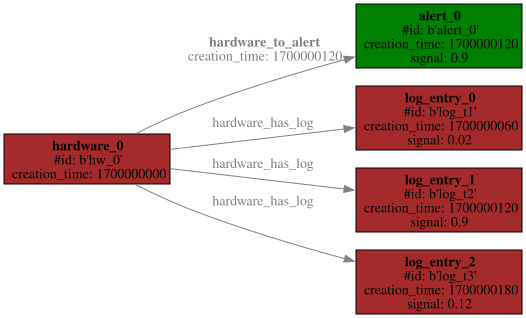

In [2]:
#@title Option A: Explicit Event Subgraph (Click to toggle code)
schema_a = dgf.data.GraphSchema(
    node_sets={
        "hardware": dgf.data.NodeSchema(
            features={
                "#id": dgf.data.FeatureSchema(format=dgf.data.FeatureFormat.BYTES),
                "creation_time": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.INTEGER_64,
                    semantic=dgf.data.FeatureSemantic.TIMESTAMP,
                    is_creation_time=True,
                ),
            }
        ),
        "log_entry": dgf.data.NodeSchema(
            features={
                "#id": dgf.data.FeatureSchema(format=dgf.data.FeatureFormat.BYTES),
                "creation_time": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.INTEGER_64,
                    semantic=dgf.data.FeatureSemantic.TIMESTAMP,
                    is_creation_time=True,
                ),
                "signal": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.FLOAT_32,
                    semantic=dgf.data.FeatureSemantic.NUMERICAL,
                ),
            }
        ),
        "alert": dgf.data.NodeSchema(
            features={
                "#id": dgf.data.FeatureSchema(format=dgf.data.FeatureFormat.BYTES),
                "creation_time": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.INTEGER_64,
                    semantic=dgf.data.FeatureSemantic.TIMESTAMP,
                    is_creation_time=True,
                ),
                "signal": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.FLOAT_32,
                    semantic=dgf.data.FeatureSemantic.NUMERICAL,
                ),
            }
        ),
    },
    edge_sets={
        "hardware_has_log": dgf.data.EdgeSchema(
            source="hardware",
            target="log_entry",
        ),
        "hardware_to_alert": dgf.data.EdgeSchema(
            source="hardware",
            target="alert",
            features={
                "creation_time": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.INTEGER_64,
                    semantic=dgf.data.FeatureSemantic.TIMESTAMP,
                    is_creation_time=True,
                ),
            },
        ),
    },
)

graph_a = dgf.data.InMemoryGraph(
    node_sets={
        "hardware": dgf.data.InMemoryNodeSet(
            num_nodes=1,
            features={
                "#id": np.array([b"hw_0"]),
                "creation_time": np.array([1700000000], dtype=np.int64),
            },
        ),
        "log_entry": dgf.data.InMemoryNodeSet(
            num_nodes=3,
            features={
                "#id": np.array([b"log_t1", b"log_t2", b"log_t3"]),
                "creation_time": np.array([1700000060, 1700000120, 1700000180], dtype=np.int64),
                "signal": np.array([0.02, 0.9, 0.12], dtype=np.float32),
            },
        ),
        "alert": dgf.data.InMemoryNodeSet(
            num_nodes=1,
            features={
                "#id": np.array([b"alert_0"]),
                "creation_time": np.array([1700000120], dtype=np.int64),
                "signal": np.array([0.9], dtype=np.float32),
            },
        ),
    },
    edge_sets={
        "hardware_has_log": dgf.data.InMemoryEdgeSet(
            adjacency=np.array([[0, 0, 0], [0, 1, 2]], dtype=np.int64)
        ),
        "hardware_to_alert": dgf.data.InMemoryEdgeSet(
            adjacency=np.array([[0], [0]], dtype=np.int64),
            features={
                "creation_time": np.array([1700000120], dtype=np.int64),
            },
        ),
    },
)

dgf.plot.plot_graph(graph_a, schema_a)

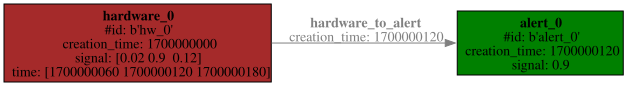

In [3]:
#@title Option B: Native Timeseries Feature (Click to toggle code)
schema_b = dgf.data.GraphSchema(
    node_sets={
        "hardware": dgf.data.NodeSchema(
            features={
                "#id": dgf.data.FeatureSchema(format=dgf.data.FeatureFormat.BYTES),
                "creation_time": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.INTEGER_64,
                    semantic=dgf.data.FeatureSemantic.TIMESTAMP,
                    is_creation_time=True,
                ),
                "time": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.INTEGER_64,
                    semantic=dgf.data.FeatureSemantic.TIMESTAMP,
                    shape=(None,),
                    is_timeseries=True,
                    group="telemetry",
                ),
                "signal": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.FLOAT_32,
                    semantic=dgf.data.FeatureSemantic.NUMERICAL,
                    shape=(None,),
                    is_timeseries=True,
                    group="telemetry",
                ),
            }
        ),
        "alert": dgf.data.NodeSchema(
            features={
                "#id": dgf.data.FeatureSchema(format=dgf.data.FeatureFormat.BYTES),
                "creation_time": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.INTEGER_64,
                    semantic=dgf.data.FeatureSemantic.TIMESTAMP,
                    is_creation_time=True,
                ),
                "signal": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.FLOAT_32,
                    semantic=dgf.data.FeatureSemantic.NUMERICAL,
                ),
            }
        ),
    },
    edge_sets={
        "hardware_to_alert": dgf.data.EdgeSchema(
            source="hardware",
            target="alert",
            features={
                "creation_time": dgf.data.FeatureSchema(
                    format=dgf.data.FeatureFormat.INTEGER_64,
                    semantic=dgf.data.FeatureSemantic.TIMESTAMP,
                    is_creation_time=True,
                ),
            },
        ),
    },
)

graph_b = dgf.data.InMemoryGraph(
    node_sets={
        "hardware": dgf.data.InMemoryNodeSet(
            num_nodes=1,
            features={
                "#id": np.array([b"hw_0"]),
                "creation_time": np.array([1700000000], dtype=np.int64),
                "time": np.array([[1700000060, 1700000120, 1700000180]], dtype=np.int64),
                "signal": np.array([[0.02, 0.9, 0.12]], dtype=np.float32),
            },
        ),
        "alert": dgf.data.InMemoryNodeSet(
            num_nodes=1,
            features={
                "#id": np.array([b"alert_0"]),
                "creation_time": np.array([1700000120], dtype=np.int64),
                "signal": np.array([0.9], dtype=np.float32),
            },
        ),
    },
    edge_sets={
        "hardware_to_alert": dgf.data.InMemoryEdgeSet(
            adjacency=np.array([[0], [0]], dtype=np.int64),
            features={
                "creation_time": np.array([1700000120], dtype=np.int64),
            },
        ),
    },
)

dgf.plot.plot_graph(graph_b, schema_b)

We observed that the signal peaked at timestamp 1700000120, which lead to an alert. If we want to train a model predicting the occurance of alerts, it is important the future is masked out during training. DGF will automatically perform such timeseries clipping for both options.

In these simple graphs, the alert just logs the signal at the time of its cration. Next, we load a synthetic graph similar to Option B for a regression task. But since just predicting the signal would be a bit simple, alerts now store the average signal over the last hour. If they are connected to multiple pieces of hardware, we average them.

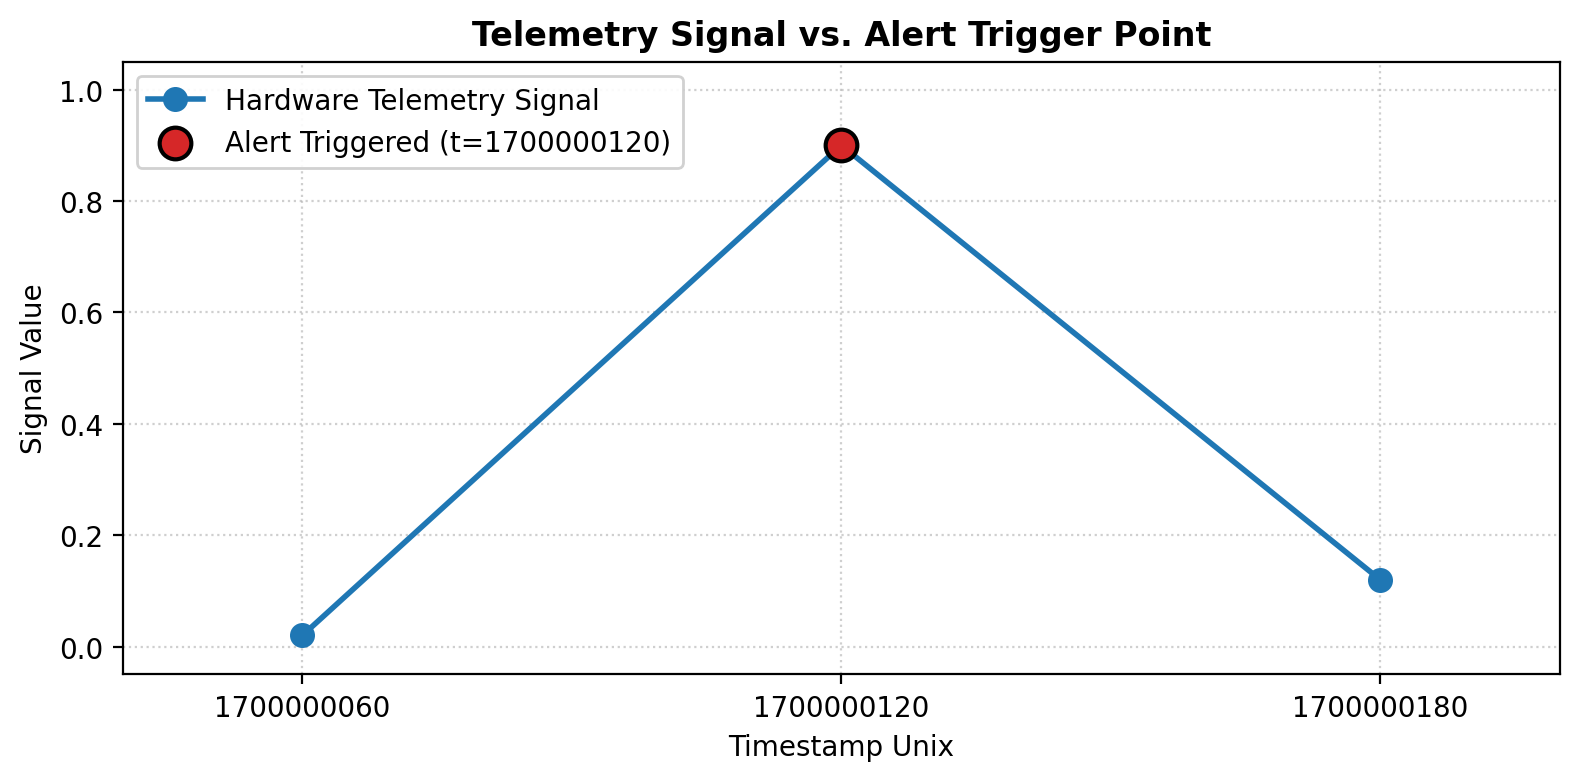

In [4]:
#@title Plot Telemetry Signal and Alert Trigger (Click to toggle code)
import matplotlib.pyplot as plt

# Retrieve telemetry data from graph_b (or fallback to graph_a)
if "graph_b" in globals():
  times = graph_b.node_sets["hardware"].features["time"][0]
  signals = graph_b.node_sets["hardware"].features["signal"][0]
  alert_time = graph_b.node_sets["alert"].features["creation_time"][0]
  alert_val = graph_b.node_sets["alert"].features["signal"][0]
  hw_t0 = graph_b.node_sets["hardware"].features["creation_time"][0]
elif "graph_a" in globals():
  times = graph_a.node_sets["log_entry"].features["creation_time"]
  signals = graph_a.node_sets["log_entry"].features["signal"]
  alert_time = graph_a.node_sets["alert"].features["creation_time"][0]
  alert_val = graph_a.node_sets["alert"].features["signal"][0]
  hw_t0 = graph_a.node_sets["hardware"].features["creation_time"][0]

# Plot the telemetry signal and the alert trigger
plt.figure(figsize=(8, 4), dpi=100)

# Telemetry signal
plt.plot(
    times,
    signals,
    marker="o",
    markersize=8,
    linewidth=2,
    color="#1f77b4",
    label="Hardware Telemetry Signal",
)

# Highlight alert trigger event
plt.scatter(
    [alert_time],
    [alert_val],
    color="#d62728",
    s=130,
    zorder=5,
    edgecolors="black",
    linewidth=1.5,
    label=f"Alert Triggered (t={alert_time})",
)


# Formatting
plt.title("Telemetry Signal vs. Alert Trigger Point", fontsize=12, fontweight="bold")
plt.xlabel("Timestamp Unix", fontsize=10)
plt.ylabel("Signal Value", fontsize=10)
plt.xticks(
    times,
    [f"{t}" for t in times],
)
plt.xlim(times[0] - 20, times[-1] + 20)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.show()

## 2. Load Synthetic Temporal Alert Graph from CNS

We load the pre-generated `alert_regression_30k_deg16` dataset (15,000 alerts, 15,000 hardware devices) directly from CNS using `dgf.io.read_graph`.

### Dataset Generation Command
If you do not have access to the CNS directory or want to generate the dataset locally or with custom parameters, run:

```bash
blaze run -c opt //third_party/py/dgf/src/bin/experimental:gen_temporal_alert_graph_main -- \
  --base_output_dir=/cns/iz-d/home/research-graph/public/graphflow_datasets/synthetic_temporal \
  --dataset_name=alert_regression_30k_deg16 \
  --num_hardware=15000 \
  --num_alerts=15000 \
  --neighbor_decay=0.8 \
  --max_hardware_per_alert=16 \
  --signal_period=7200 \
  --seed=42
```

### Why the degree cap?
The number of hardware devices attached to an alert is drawn from a geometric distribution
(`neighbor_decay=0.8`, mean 5). Its tail is long: across 15,000 alerts the largest in-degree is
around 43. Those few hub alerts produce sampled subgraphs far larger than the typical one, which
forces the batch padding to be sized for the worst case.

`--max_hardware_per_alert=16` clips that tail while leaving the bulk of the data untouched: the mean
in-degree only drops from 5.00 to `(1 - 0.8^16) / 0.2 = 4.86`, i.e. ~3% fewer edges.

### Graph Structure & Domain Model
This bipartite, heterogeneous temporal graph models hardware monitoring alerts:
- **`hardware` nodes**: Physical machines emitting telemetry signals over time.
  - `#id`: Unique primary identifier.
  - `creation_time`: Base timestamp when the device became active.
  - `time` & `signal` (dynamic timeseries): Timestamped sensor telemetry readings.
- **`alerts` nodes**: Incident events triggered at specific points in time.
  - `#id`: Unique primary identifier.
  - `creation_time`: The timestamp when the alert fired.
  - `signal_regression` (target): The continuous regression label to predict, representing the time- and neighbor-averaged telemetry signals over the 1-hour lookback window.
- **`hardware_to_alert` edges**: Directed edges connecting hardware entities to the alerts they triggered.

We first load and validate the graph.

In [5]:
DATASET_PATH = "/cns/iz-d/home/research-graph/public/graphflow_datasets/synthetic_temporal/alert_regression_30k_deg16"

graph, schema = dgf.io.read_graph(DATASET_PATH)
dgf.validate.validate_graph(graph, schema)

Graph read in memory in 15.97s


### Inspect Graph Schema

Next, we inspect the node features and timestamps via `dgf.print.schema`:


In [6]:
dgf.print.schema(schema)

Graph Schema:

Node Sets:
  alerts:
    | Feature           | Format     | Semantic   | Shape   | Num cat. vals   |
    |-------------------|------------|------------|---------|-----------------|
    | #id               | BYTES      | PRIMARY_ID | None    | None            |
    | creation_time     | INTEGER_64 | TIMESTAMP  | None    | None            |
    | signal_regression | FLOAT_32   | NUMERICAL  | None    | None            |

  hardware:
    | Feature       | Format     | Semantic   | Shape   | Num cat. vals   |
    |---------------|------------|------------|---------|-----------------|
    | #id           | BYTES      | PRIMARY_ID | None    | None            |
    | creation_time | INTEGER_64 | TIMESTAMP  | None    | None            |
    | signal        | FLOAT_32   | NUMERICAL  | (None,) | None            |
    | time          | INTEGER_64 | TIMESTAMP  | (None,) | None            |


Edge Sets:
  hardware_to_alert: (Source: hardware, Target: alerts)
    | Feature       | Form

## 3. Chronological Temporal Train / Validation Split

In temporal graph learning, a random train / validation split leaks future information into the training set. Therefore, when `time_aware=True`, `dgf.learning.train_node_model` splits the seed nodes **chronologically** instead of randomly, using the creation timestamp of the target nodeset. The size of the split is controlled by `validation_ratio`:
- **Past alerts (80%)**: Used as training set.
- **Future alerts (20%)**: Used as validation set.

No manual split is required. The plot below illustrates this split with two alert nodes, one from the training and one from the validation period, together with their respective timeseries. In the signal regression graph, the predicted signal at an alert depends on the previous hour (shaded).

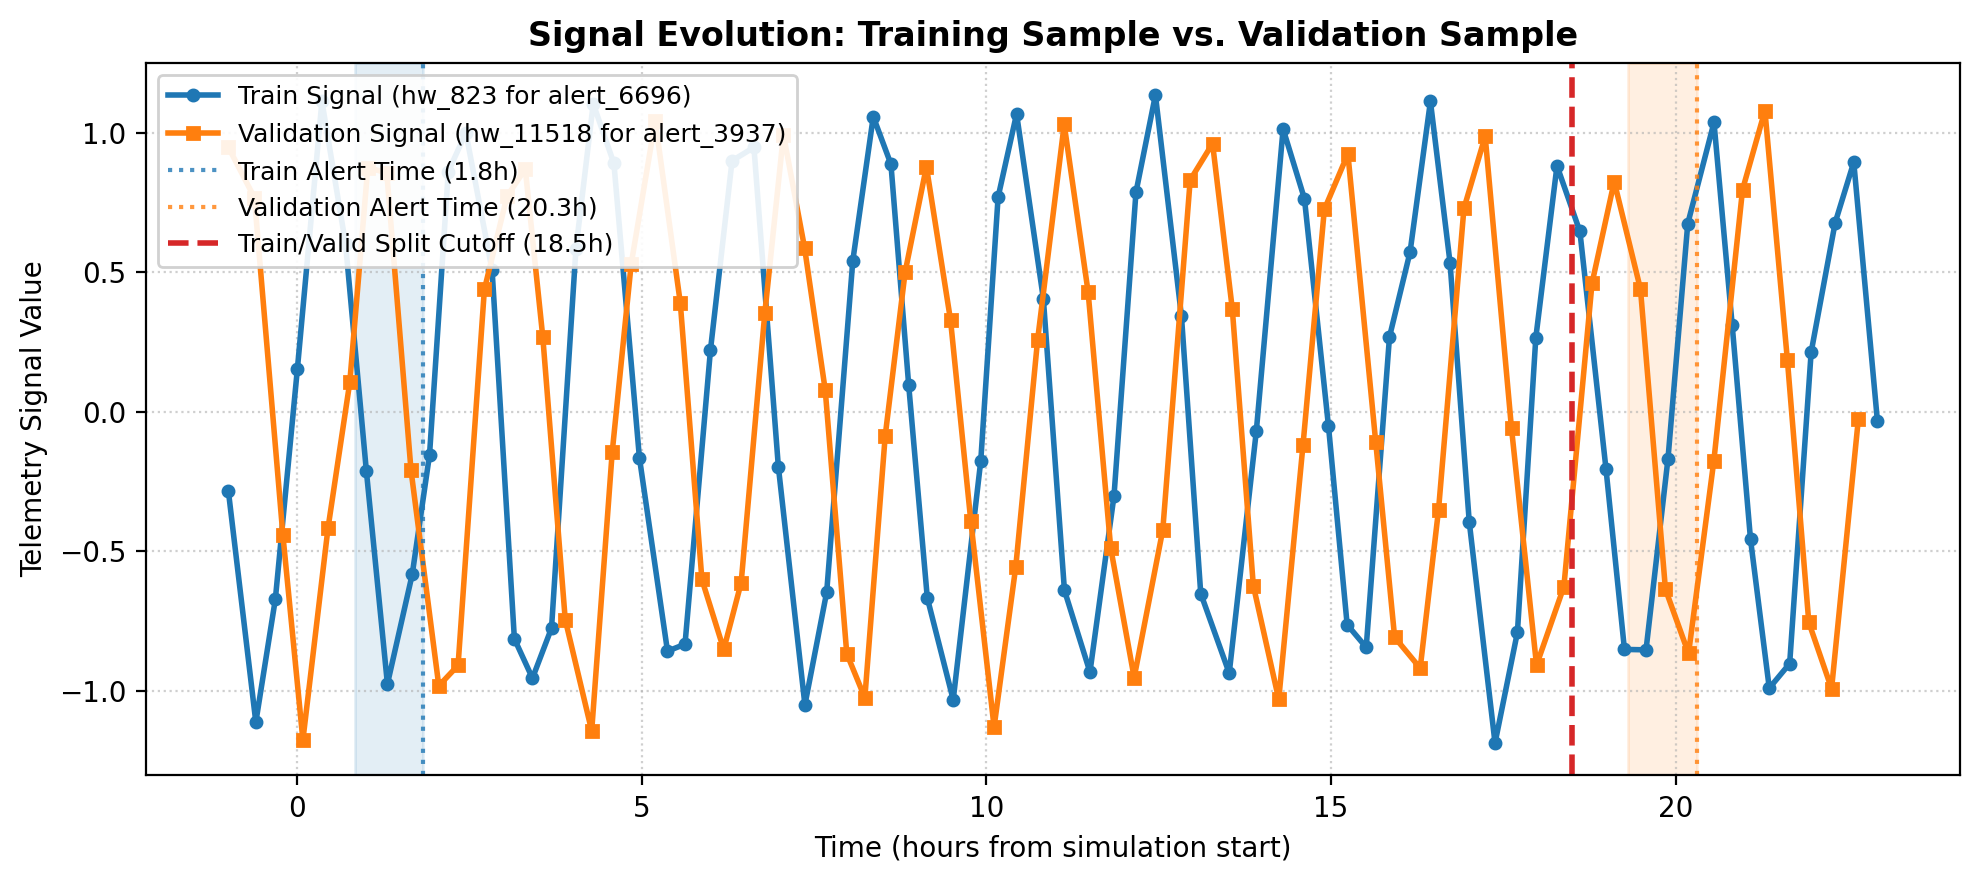

In [7]:
#@title Plot Train vs. Validation Signal Evolution (Click to toggle code)
import matplotlib.pyplot as plt

# Same validation ratio as the one given to `train_node_model` below.
VALIDATION_RATIO = 0.2
# The regression target depends on the telemetry observed in this window.
LOOKBACK_SECONDS = 3600.0

# 1. Reproduce the chronological split for illustration: the alerts are sorted
#    by creation time, the oldest ones are used for training and the most
#    recent ones for validation.
alert_timestamps = graph.node_sets["alerts"].features["creation_time"]
chronological_alerts = np.argsort(alert_timestamps, kind="stable")
num_valid_alerts = int(len(chronological_alerts) * VALIDATION_RATIO)
train_alert_idxs = chronological_alerts[:-num_valid_alerts]
valid_alert_idxs = chronological_alerts[-num_valid_alerts:]

# 2. Pick one alert from the training period and one from the validation
#    period. Both are sorted chronologically, so we skip the first alerts to
#    get a validation alert that is clearly after the split cutoff.
train_alert_idx = int(train_alert_idxs[1200])
valid_alert_idx = int(valid_alert_idxs[1200])

# 3. Find the connected hardware device for each alert
adj = graph.edge_sets["hardware_to_alert"].adjacency
train_hw_matches = adj[0][adj[1] == train_alert_idx]
valid_hw_matches = adj[0][adj[1] == valid_alert_idx]

train_hw_idx = train_hw_matches[0] if len(train_hw_matches) > 0 else 0
valid_hw_idx = valid_hw_matches[0] if len(valid_hw_matches) > 0 else 1

# 4. Retrieve their telemetry signals over time
train_times = graph.node_sets["hardware"].features["time"][train_hw_idx]
train_signal = graph.node_sets["hardware"].features["signal"][train_hw_idx]

valid_times = graph.node_sets["hardware"].features["time"][valid_hw_idx]
valid_signal = graph.node_sets["hardware"].features["signal"][valid_hw_idx]

# Reference start timestamp and conversion to hours
t0 = alert_timestamps.min()
to_hours = lambda t: (t - t0) / 3600.0

# The split cutoff is the timestamp of the first (earliest) validation alert.
split_time = alert_timestamps[valid_alert_idxs[0]]
train_alert_t = alert_timestamps[train_alert_idx]
valid_alert_t = alert_timestamps[valid_alert_idx]

# 5. Plot both signals evolving over time
plt.figure(figsize=(10, 4.5), dpi=100)

# Training signal (blue)
plt.plot(
    to_hours(train_times),
    train_signal,
    color="#1f77b4",
    linewidth=2,
    marker="o",
    markersize=4,
    label=f"Train Signal (hw_{train_hw_idx} for alert_{train_alert_idx})",
)

# Validation signal (orange)
plt.plot(
    to_hours(valid_times),
    valid_signal,
    color="#ff7f0e",
    linewidth=2,
    marker="s",
    markersize=4,
    label=f"Validation Signal (hw_{valid_hw_idx} for alert_{valid_alert_idx})",
)

# Mark the respective alert occurrences
plt.axvline(
    to_hours(train_alert_t),
    color="#1f77b4",
    linestyle=":",
    linewidth=1.5,
    alpha=0.8,
    label=f"Train Alert Time ({to_hours(train_alert_t):.1f}h)",
)
plt.axvline(
    to_hours(valid_alert_t),
    color="#ff7f0e",
    linestyle=":",
    linewidth=1.5,
    alpha=0.8,
    label=f"Validation Alert Time ({to_hours(valid_alert_t):.1f}h)",
)

# Shade the 1h look-back window preceding each alert: this is the period the
# alert signal regression depends on.
plt.axvspan(
    to_hours(train_alert_t - LOOKBACK_SECONDS),
    to_hours(train_alert_t),
    color="#1f77b4",
    alpha=0.12,
)
plt.axvspan(
    to_hours(valid_alert_t - LOOKBACK_SECONDS),
    to_hours(valid_alert_t),
    color="#ff7f0e",
    alpha=0.12,
)

# Chronological split cutoff
plt.axvline(
    to_hours(split_time),
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label=f"Train/Valid Split Cutoff ({to_hours(split_time):.1f}h)",
)

plt.title(
    "Signal Evolution: Training Sample vs. Validation Sample",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Time (hours from simulation start)", fontsize=10)
plt.ylabel("Telemetry Signal Value", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left", framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()

## 4. Train Time-Aware Temporal Node Prediction Model

We use DGF's high-level training API:
- `target_nodeset="alerts"`: Predict target feature on the `alerts` nodes.
- `target_column="signal_regression"`: Target continuous regression feature.
- `time_aware=True`: Enforces temporal masking during sampling, and splits the training and validation sets chronologically.
- `validation_ratio=0.2`: The most recent 20% of the alerts are used for validation, the older 80% for training.

We train for 15'000 steps. If you do not have access to a GPU this takes a couple minutes unless you reduce the amount of steps.

In [8]:
# Train the model with time-aware causal sampling. The train / validation
# split is done chronologically (past alerts for training, future alerts for
# validation).
model = dgf.learning.train_node_model(
    graph=graph,
    schema=schema,
    target_nodeset="alerts",
    target_column="signal_regression",
    time_aware=True,
    validation_ratio=0.2,
    num_train_steps=15_000,
    batch_size=32,
    verbose=2,
)

Using gpu JAX backend
Graph input schema:
Node Sets:
  alerts:
    | Feature           | Format     | Semantic   | Shape   | Num cat. vals   |
    |-------------------|------------|------------|---------|-----------------|
    | #id               | BYTES      | PRIMARY_ID | None    | None            |
    | creation_time     | INTEGER_64 | TIMESTAMP  | None    | None            |
    | signal_regression | FLOAT_32   | NUMERICAL  | None    | None            |

  hardware:
    | Feature       | Format     | Semantic   | Shape   | Num cat. vals   |
    |---------------|------------|------------|---------|-----------------|
    | #id           | BYTES      | PRIMARY_ID | None    | None            |
    | creation_time | INTEGER_64 | TIMESTAMP  | None    | None            |
    | signal        | FLOAT_32   | NUMERICAL  | (None,) | None            |
    | time          | INTEGER_64 | TIMESTAMP  | (None,) | None            |


Edge Sets:
  hardware_to_alert: (Source: hardware, Target: alerts)

[Warning] No normalizer created for node set 'hardware', feature '#id'.
[Warning] No normalizer created for node set 'alerts', feature '#id'.


Preparing dataset finished in 2.70 seconds
Normalizer:
Graph Normalizer:

Node Sets:
  alerts:
    - creation_time: SequentialNormalizer
    - signal_regression: IdentityNormalizer

  hardware:
    - creation_time: SequentialNormalizer
    - signal: SoftQuantileNormalizer
    - time: SequentialNormalizer
    - time_mask: IdentityNormalizer

Edge Sets:
  hardware_to_alert: (Source: hardware, Target: alerts)
    (No normalizers)

Normalized graph schema:
Node Sets:
  alerts:
    | Feature                           | Format   | Semantic   | Shape   | Num cat. vals   |
    |-----------------------------------|----------|------------|---------|-----------------|
    | creation_time_seed_delta_SINUSOID | FLOAT_32 | EMBEDDING  | (32,)   | None            |
    | signal_regression                 | FLOAT_32 | NUMERICAL  | None    | None            |

  hardware:
    | Feature                           | Format   | Semantic   | Shape    | Num cat. vals   |
    |---------------------------------

Caching validation dataset:  17%|█▋        | 16/93 [00:00<00:04, 16.73it/s]

Caching validation dataset finished in 0.96 seconds
Number of cache validation batches: 16
Training model


...

step:15000 train-loss:0.0010 train-rmse:0.0316 valid-loss:0.0006 valid-rmse:0.0243
Restoring best model parameters with validation loss 0.000611 from step 15000
Final metrics: {'step': '15000', 'train-loss': '0.0010', 'train-rmse': '0.0316', 'valid-loss': '0.0006', 'valid-rmse': '0.0243'}
Training model finished in 298.65 seconds
Final model evaluation
Evaluating model on generator



Evaluation:   0%|          | 0/10000 [00:00<?, ?it/s]

...Tracing model


Evaluation:  30%|███       | 3000/10000 [00:04<00:09, 703.67it/s] 

...Tracing model


## 5. Examine Model

It is important to look at the trained model.  

In [9]:
model.describe()

Type,Node prediction model - Predict the value of a node feature.
Target nodeset,alerts
Target column,signal_regression
Number of label classes,1
WARNING,"No normalizer created for node set 'hardware', feature '#id'."
WARNING,"No normalizer created for node set 'alerts', feature '#id'."
RMSE,0.025249014309569356
R2,0.9913621544837952
Num Examples,3000
Number of training seed nodes,12000
Number of validation seed nodes,3000


## 6. Evaluate Model

We finally evaluate the model on the validation alerts, i.e. the most recent 20% of the alerts that were held out during training. We see that most of the variance is explained by our model.

In [10]:
model.evaluate(graph, seed_node_idxs=valid_alert_idxs, num_eval_steps=3000)

Evaluating model on 3000 samples


Inference: 100%|██████████| 188/188 [00:01<00:00, 94.81it/s]


RMSE,0.025240105922031367
R2,0.9913682341575623
Num Examples,3000
